# MTM-only re-score of the MTM settings results (Fusion_PhD-bhx7.9)

User, 2026-10-02: "This needs to be an MTM database, we should be using the rules I established to remove anything that isn't an MTM." (`docs/mode_filtering.md`, "Populations".)

**Population.** NSTX_MTM GS2 cases with $\gamma_{GS2} > 10^{-3}$ whose GS2 dominant mode `general_analysis.mode_classification.classify` labels MTM ($T > 0.15$ and $\omega < 0$; `Fusion_PhD-lqwx`, GA master `77e04d9`). Everything else (KBM, mixed, GS2-stable) is removed and the count is printed.

**Scoring the code (user, 2026-10-02).** GFTM is never filtered. Its dominant mode (argmax $\gamma$ over `mode`) is scored whatever its type. *Capture* = that mode is an MTM by $T>0.15$ and $\omega<0$. A dominant mode that is not an MTM is a capture failure whose growth-rate error still counts in medlog / medAE. No unstable mode, or no deck, is a MISS ($+\infty$), kept.

GFTM's $T$ is the pyro formula $|\int A_\parallel d\theta| / \int |A_\parallel| d\theta$ on the stored theta-resolved `apar` of the dominant mode (unit $dl$ weight, Simpson). For the two max-basis arms the stored `tearing_parameter` exists; the agreement is checked below.

## Imports and settings

In [1]:
from pathlib import Path
import os
from multiprocessing import Pool
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from scipy.integrate import simpson
from pyrokinetics import Pyro, PyroHypercube
from general_analysis.mode_classification import indicators, classify, T_TEAR

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file() and (p / "notebooks").is_dir())
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
plt.rcParams.update({"axes.titlesize": 16, "axes.labelsize": 16, "xtick.labelsize": 14, "ytick.labelsize": 14, "legend.fontsize": 12})
load_dotenv(ROOT / "local.env", override=True)

analysis_name = "mtm_only_rescore"
data_root = Path(os.environ["GK_DATA_ROOT"]).expanduser()
base = data_root / "GFTM/Runs/LATIN_HYPERCUBE/NSTX_MTM"
gs2_base = data_root / "GS2/Runs/LATIN_HYPERCUBE/NSTX_MTM"

# label -> (leaf, folder with the cube, file kind)
arms_all = {
    "A maxbasis s=1":    ("extent_maxbasis_s100", "", "gyrorun"),
    "B maxbasis s=1.41": ("extent_maxbasis_s141", "", "gyrorun"),
    "m11_new":           ("m11_new", "pyro_cube", "cube"),
    "m9_new":            ("m9_new", "pyro_cube", "cube"),
    "rule s=1":          ("extent_rule_tf035", "pyro_cube", "cube"),
    "rule s=1.41":       ("extent_rule_tf035_s141", "pyro_cube", "cube"),
    "fw174":             ("gftm_fw174", "pyro_cube", "cube"),
}
draws = {"n1000": ("beta_q_shat_ky_n1000", list(arms_all)),
         "n300":  ("beta_q_shat_ky_n300", [a for a in arms_all if "maxbasis" not in a])}
gs2_unstable = 1e-3
n_boot, seed = 2000, 0

## Load and score

Per draw: the GS2 cube (`pyro_cube_avg`, tail-averaged $\gamma$ as in every earlier analysis), the GS2 classifier label per GS2-unstable case (final-time indicators from each run directory, as in `lqwx`), and every GFTM arm's dominant-mode $\gamma$, $\omega$, $T$.

In [2]:
def gs2_label(d):
    p = Pyro(gk_file=d / "gs2.in")
    p.load_gk_output()
    ind = indicators(p)
    return classify(ind), ind["T"], ind["omega"]

def tearing(ds):
    """(sample, mode) |int A dtheta| / int |A| dtheta, as pyro's compute_linear_tearing_parameter with dl = 1."""
    a = np.asarray(ds.eigenfunctions.sel(field="apar").transpose("sample", "mode", "theta").values)
    th = np.asarray(ds.theta.values, float)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.abs(simpson(a, x=th, axis=-1)) / simpson(np.abs(a), x=th, axis=-1)

def dom(ds, v):
    """Value of (sample, mode) array v at each sample's dominant (argmax gamma) mode."""
    g = np.asarray(ds.growth_rate.transpose("sample", "mode").values, float)
    k = np.where(np.isfinite(g), g, -np.inf).argmax(axis=1)
    return v[np.arange(len(k)), k]

D = {}
for dname, (draw, arms) in draws.items():
    d = gs2_base / draw / "pyro_cube_avg"
    cube = PyroHypercube(pyroscan_json=d / "pyroscan.json", load_base_pyro=True)
    cube.from_netcdf(d / "cube.nc")
    gs2 = cube.gk_output.data
    names = [str(n) for n in gs2.sample_name.values]
    gamma_gs2 = np.asarray(gs2.growth_rate.values, float).reshape(len(names), -1)[:, 0]
    unstable = gamma_gs2 > gs2_unstable
    idx = np.flatnonzero(unstable)
    with Pool(int(os.environ.get("SLURM_CPUS_PER_TASK", 4))) as pool:
        res = pool.map(gs2_label, [Path(cube.base_directory) / names[i] for i in idx], chunksize=4)
    label = np.full(len(names), "", dtype=object)
    for i, (c, _, _) in zip(idx, res):
        label[i] = c
    rec = dict(names=names, gamma_gs2=gamma_gs2, unstable=unstable, label=label, arm={})
    for arm in arms:
        leaf, sub, kind = arms_all[arm]
        dd = base / draw / leaf / sub
        c = PyroHypercube(pyroscan_json=dd / "pyroscan.json", load_base_pyro=True)
        if kind == "gyrorun":
            c.load_gk_output(netcdf_file=dd / "pyroscan.nc")
        else:
            c.from_netcdf(dd / "cube.nc")
        ds = c.gk_output.data
        row = {str(n): i for i, n in enumerate(ds.sample_name.values)}
        take = np.array([row.get(n, -1) for n in names])
        have, t = take >= 0, np.maximum(take, 0)
        g = np.asarray(ds.growth_rate.transpose("sample", "mode").values, float)
        om = np.asarray(ds.mode_frequency.transpose("sample", "mode").values, float)
        T = tearing(ds)
        a = dict(have=have, gamma=np.where(have, dom(ds, g)[t], np.nan), omega=np.where(have, dom(ds, om)[t], np.nan),
                 T=np.where(have, dom(ds, T)[t], np.nan))
        if "tearing_parameter" in ds:
            Ts = ds.tearing_parameter.isel(kx=0, drop=True, missing_dims="ignore").transpose("sample", "mode").values
            a["T_stored"] = np.where(have, dom(ds, np.asarray(Ts, float))[t], np.nan)
        rec["arm"][arm] = a
        print(dname, arm, "decks", int(have.sum()))
    D[dname] = rec
    lab = label[unstable]
    print(dname, f"{len(names)} cases, GS2-unstable {unstable.sum()}:", {c: int((lab == c).sum()) for c in ("MTM", "KBM", "mixed")})

/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


...

n300 rule s=1 decks 297


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


n300 rule s=1.41 decks 297


n300 fw174 decks 300
n300 300 cases, GS2-unstable 269: {'MTM': 210, 'KBM': 37, 'mixed': 22}


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


## Population and the removed count

In [3]:
for dname, r in D.items():
    n, nu = len(r["names"]), int(r["unstable"].sum())
    lab = r["label"][r["unstable"]]
    nm = int((lab == "MTM").sum())
    r["mtm"] = r["unstable"] & (r["label"] == "MTM")
    print(f"{dname}: {n} cases | GS2-stable {n - nu} | KBM {int((lab == 'KBM').sum())} | mixed {int((lab == 'mixed').sum())} "
          f"| MTM kept {nm} | removed {n - nm} of {n} ({nu - nm} of {nu} GS2-unstable)")

n1000: 1000 cases | GS2-stable 96 | KBM 136 | mixed 57 | MTM kept 711 | removed 289 of 1000 (193 of 904 GS2-unstable)
n300: 300 cases | GS2-stable 31 | KBM 37 | mixed 22 | MTM kept 210 | removed 90 of 300 (59 of 269 GS2-unstable)


## GFTM $T$ check, and capture

`T` from the stored theta-resolved `apar` against the `tearing_parameter` the GyroRun save job stored (arms A, B). Capture = $\gamma>0$ and $\omega<0$ and $T>0.15$ on the dominant mode.

In [4]:
for dname, r in D.items():
    for arm, a in r["arm"].items():
        a["mtm_mode"] = a["have"] & (a["gamma"] > 0) & (a["omega"] < 0) & (a["T"] > T_TEAR)
        if "T_stored" in a:
            ok = a["have"] & np.isfinite(a["T_stored"])
            dT = np.abs(a["T"] - a["T_stored"])[ok]
            flip = ((a["T"] > T_TEAR) != (a["T_stored"] > T_TEAR))[ok]
            print(f"{dname} {arm}: |T - T_stored| median {np.median(dT):.2e}, max {dT.max():.2e}; side of 0.15 differs on {int(flip.sum())} of {int(ok.sum())}")

n1000 A maxbasis s=1: |T - T_stored| median 5.03e-03, max 1.21e-01; side of 0.15 differs on 3 of 987
n1000 B maxbasis s=1.41: |T - T_stored| median 4.61e-03, max 7.97e-02; side of 0.15 differs on 4 of 984


## Score every arm on the MTM-only population

medlog = median $|\log_{10}(\gamma_{GFTM}/\gamma_{GS2})|$, medAE = median $|\gamma_{GFTM}-\gamma_{GS2}|$, dominant mode, misses $+\infty$, capture failures scored on their own $\gamma$. 95% bootstrap intervals; the same resampled cases for every arm.

In [5]:
def score(r, arm, mask):
    a = r["arm"][arm]
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = a["gamma"] / r["gamma_gs2"]
    pos = a["have"] & (a["gamma"] > 0)
    e = np.where(pos, np.abs(np.log10(ratio)), np.inf)
    ae = np.where(pos, np.abs(a["gamma"] - r["gamma_gs2"]), np.inf)
    cap = a["mtm_mode"]
    return dict(e=e[mask], ae=ae[mask], cap=cap[mask], miss=~pos[mask])

rng = np.random.default_rng(seed)
def table(r, arms, mask):
    n = int(mask.sum())
    b = rng.integers(0, n, (n_boot, n))
    out = {}
    for arm in arms:
        s = score(r, arm, mask)
        bm = np.median(s["e"][b], axis=1)
        out[arm] = dict(n=n, medlog=np.median(s["e"]), ci=np.percentile(bm, [2.5, 97.5]), medae=np.median(s["ae"]),
                        capture=s["cap"].mean(), cap_ci=np.percentile(s["cap"][b].mean(axis=1), [2.5, 97.5]),
                        capfail=int((~s["cap"] & ~s["miss"]).sum()), misses=int(s["miss"].sum()))
    return out

T1 = {}
for dname, r in D.items():
    arms = draws[dname][1]
    T1[dname] = table(r, arms, r["mtm"])
    allcase = table(r, arms, r["unstable"])
    print(f"\n{dname}: MTM-only n={int(r['mtm'].sum())} (removed {len(r['names']) - int(r['mtm'].sum())} of {len(r['names'])}); "
          f"all GS2-unstable n={int(r['unstable'].sum())} shown for reference only (superseded headline)")
    print(f"{'arm':18s} medlog [95% CI] | medAE | capture [95% CI] | capture failures | misses || all-case medlog")
    for arm in arms:
        t = T1[dname][arm]
        print(f"{arm:18s} {t['medlog']:.3f} [{t['ci'][0]:.3f},{t['ci'][1]:.3f}] | {t['medae']:.4f} | {t['capture']:.3f} "
              f"[{t['cap_ci'][0]:.3f},{t['cap_ci'][1]:.3f}] | {t['capfail']:3d} | {t['misses']:3d} || {allcase[arm]['medlog']:.3f}")

/tmp/ipykernel_1575694/688656429.py:6: RuntimeWarning: divide by zero encountered in log10
  e = np.where(pos, np.abs(np.log10(ratio)), np.inf)
/tmp/ipykernel_1575694/688656429.py:6: RuntimeWarning: invalid value encountered in log10
  e = np.where(pos, np.abs(np.log10(ratio)), np.inf)



n1000: MTM-only n=711 (removed 289 of 1000); all GS2-unstable n=904 shown for reference only (superseded headline)
arm                medlog [95% CI] | medAE | capture [95% CI] | capture failures | misses || all-case medlog
A maxbasis s=1     0.341 [0.309,0.359] | 0.1226 | 0.828 [0.800,0.855] | 121 |   1 || 0.285
B maxbasis s=1.41  0.313 [0.292,0.349] | 0.1169 | 0.812 [0.782,0.840] | 130 |   4 || 0.250
m11_new            0.281 [0.249,0.315] | 0.0869 | 0.719 [0.685,0.752] | 190 |  10 || 0.276
m9_new             0.288 [0.257,0.329] | 0.0931 | 0.685 [0.648,0.719] | 208 |  16 || 0.293
rule s=1           0.405 [0.371,0.438] | 0.1449 | 0.759 [0.729,0.792] | 138 |  33 || 0.387
rule s=1.41        0.352 [0.326,0.385] | 0.1377 | 0.792 [0.762,0.820] | 119 |  29 || 0.327
fw174              0.478 [0.448,0.548] | 0.0970 | 0.498 [0.461,0.533] | 296 |  61 || 0.357

n300: MTM-only n=210 (removed 90 of 300); all GS2-unstable n=269 shown for reference only (superseded headline)
arm                medlog

## The shortest-extent quartile removed (`drop_q1`, `Fusion_PhD-1c88` definition)

Extent = the `rule s=1.41` arm's achieved one-sided reach, $\mathrm{WIDTH}_{used}\,x_{max}(\mathrm{NXGRID}_{used})$ in units of $\pi$ (a property of the case, applied identically to every arm). Q1 = below the 25th percentile of the **MTM-only** population (the old cut used all GS2-unstable cases). Cases with no `rule s=1.41` deck have no extent: they stay in the full population and are in neither the cut nor Q1; their number is printed.

In [6]:
nodes = lambda n: np.polynomial.hermite.hermgauss(2 * int(n) - 1)[0]
Q = {}
for dname, r in D.items():
    leaf = arms_all["rule s=1.41"]
    dd = base / draws[dname][0] / leaf[0] / leaf[1]
    c = PyroHypercube(pyroscan_json=dd / "pyroscan.json", load_base_pyro=True)
    c.from_netcdf(dd / "cube.nc")
    ds = c.gk_output.data
    row = {str(n): i for i, n in enumerate(ds.sample_name.values)}
    reach = np.full(len(r["names"]), np.nan)
    for j, n in enumerate(r["names"]):
        if n in row:
            i = row[n]
            reach[j] = float(ds.width_used.values[i]) * nodes(ds.nxgrid_used.values[i]).max() / np.pi
    r["reach"] = reach
    m = r["mtm"] & np.isfinite(reach)
    q1_cut = np.percentile(reach[m], 25)
    pops = {"full": r["mtm"], "Q1 removed": m & (reach >= q1_cut), "Q1 alone": m & (reach < q1_cut)}
    Q[dname] = {p: table(r, draws[dname][1], mk) for p, mk in pops.items()}
    print(f"\n{dname}: Q1 upper extent {q1_cut:.3f} pi; MTM n={int(r['mtm'].sum())}, no extent {int((r['mtm'] & ~np.isfinite(reach)).sum())}, "
          f"cut n={int(pops['Q1 removed'].sum())}, Q1 n={int(pops['Q1 alone'].sum())}")
    for p in pops:
        print(f"  {p} -- medlog / medAE / capture / misses")
        for arm in draws[dname][1]:
            t = Q[dname][p][arm]
            print(f"    {arm:18s} {t['medlog']:.3f} / {t['medae']:.4f} / {t['capture']:.2f} / {t['misses']}")

/tmp/ipykernel_1575694/688656429.py:6: RuntimeWarning: divide by zero encountered in log10
  e = np.where(pos, np.abs(np.log10(ratio)), np.inf)
/tmp/ipykernel_1575694/688656429.py:6: RuntimeWarning: invalid value encountered in log10
  e = np.where(pos, np.abs(np.log10(ratio)), np.inf)



n1000: Q1 upper extent 6.108 pi; MTM n=711, no extent 9, cut n=526, Q1 n=176
  full -- medlog / medAE / capture / misses
    A maxbasis s=1     0.341 / 0.1226 / 0.83 / 1
    B maxbasis s=1.41  0.313 / 0.1169 / 0.81 / 4
    m11_new            0.281 / 0.0869 / 0.72 / 10
    m9_new             0.288 / 0.0931 / 0.68 / 16
    rule s=1           0.405 / 0.1449 / 0.76 / 33
    rule s=1.41        0.352 / 0.1377 / 0.79 / 29
    fw174              0.478 / 0.0970 / 0.50 / 61
  Q1 removed -- medlog / medAE / capture / misses
    A maxbasis s=1     0.330 / 0.0930 / 0.83 / 1
    B maxbasis s=1.41  0.301 / 0.0814 / 0.82 / 1
    m11_new            0.218 / 0.0554 / 0.75 / 4
    m9_new             0.213 / 0.0530 / 0.63 / 12
    rule s=1           0.330 / 0.0893 / 0.79 / 18
    rule s=1.41        0.290 / 0.0835 / 0.80 / 7
    fw174              0.517 / 0.0735 / 0.49 / 55
  Q1 alone -- medlog / medAE / capture / misses
    A maxbasis s=1     0.367 / 0.3669 / 0.82 / 0
    B maxbasis s=1.41  0.433 / 0.3181


n300: Q1 upper extent 6.903 pi; MTM n=210, no extent 3, cut n=155, Q1 n=52
  full -- medlog / medAE / capture / misses
    m11_new            0.282 / 0.0878 / 0.70 / 6
    m9_new             0.279 / 0.0751 / 0.68 / 3
    rule s=1           0.410 / 0.1164 / 0.72 / 9
    rule s=1.41        0.398 / 0.1270 / 0.76 / 9
    fw174              0.404 / 0.0736 / 0.46 / 20
  Q1 removed -- medlog / medAE / capture / misses
    m11_new            0.230 / 0.0472 / 0.74 / 4
    m9_new             0.220 / 0.0398 / 0.64 / 2
    rule s=1           0.378 / 0.0814 / 0.77 / 4
    rule s=1.41        0.340 / 0.0777 / 0.77 / 5
    fw174              0.441 / 0.0545 / 0.46 / 16
  Q1 alone -- medlog / medAE / capture / misses
    m11_new            0.489 / 0.4379 / 0.62 / 1
    m9_new             0.651 / 0.5583 / 0.83 / 0
    rule s=1           0.450 / 0.4182 / 0.62 / 2
    rule s=1.41        0.555 / 0.4039 / 0.77 / 1
    fw174              0.383 / 0.1955 / 0.50 / 2


/tmp/ipykernel_1575694/688656429.py:6: RuntimeWarning: divide by zero encountered in log10
  e = np.where(pos, np.abs(np.log10(ratio)), np.inf)
/tmp/ipykernel_1575694/688656429.py:6: RuntimeWarning: invalid value encountered in log10
  e = np.where(pos, np.abs(np.log10(ratio)), np.inf)


## Plots

Figure 1: medlog and capture per arm on the MTM-only n1000 population, with the arms' own 95% bootstrap bars. Figure 2: the same medlog with the shortest-extent quartile removed and for Q1 alone, rule $s=1.41$, `m11_new`, `m9_new`, `fw174`. Counts and definitions are in the README.

/tmp/ipykernel_1575694/1243823891.py:13: UserWarning: The figure layout has changed to tight
  fig1.tight_layout()


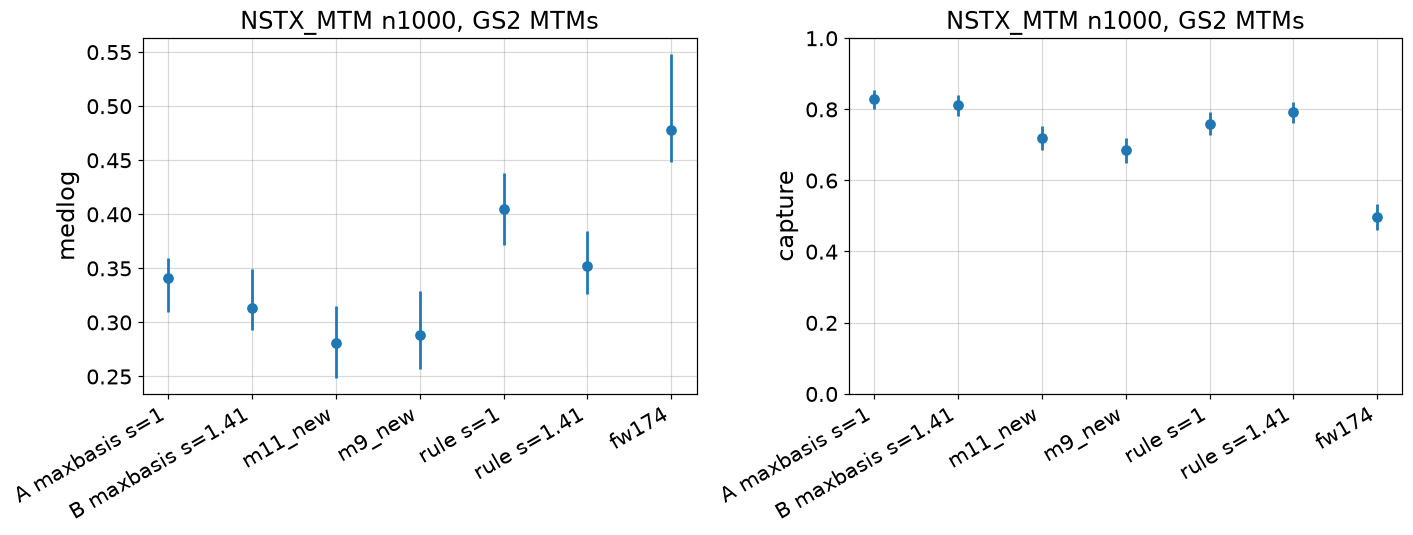

In [7]:
out = ROOT / "Plots" / analysis_name
out.mkdir(parents=True, exist_ok=True)
arms = draws["n1000"][1]
t = T1["n1000"]
x = np.arange(len(arms))
fig1, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].errorbar(x, [t[a]["medlog"] for a in arms], yerr=np.array([np.abs(t[a]["ci"] - t[a]["medlog"]) for a in arms]).T, ls="", marker="o")
ax[0].set(ylabel="medlog", title="NSTX_MTM n1000, GS2 MTMs")
ax[1].errorbar(x, [t[a]["capture"] for a in arms], yerr=np.array([np.abs(t[a]["cap_ci"] - t[a]["capture"]) for a in arms]).T, ls="", marker="o")
ax[1].set(ylabel="capture", ylim=(0, 1), title="NSTX_MTM n1000, GS2 MTMs")
for a_ in ax:
    a_.set_xticks(x, arms, rotation=30, ha="right")
fig1.tight_layout()
plt.show()

/tmp/ipykernel_1575694/3679780166.py:11: UserWarning: The figure layout has changed to tight
  fig2.tight_layout()


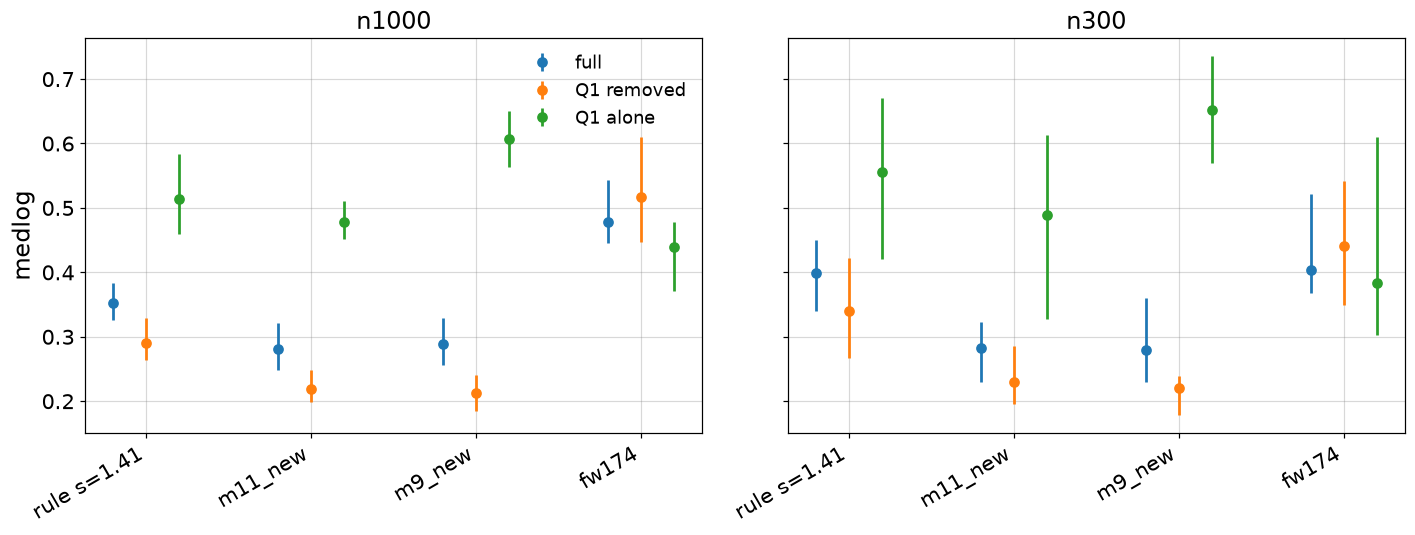

In [8]:
sub = ["rule s=1.41", "m11_new", "m9_new", "fw174"]
fig2, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for a_, dname in zip(ax, ("n1000", "n300")):
    for j, p in enumerate(("full", "Q1 removed", "Q1 alone")):
        a_.errorbar(np.arange(len(sub)) + 0.2 * (j - 1), [Q[dname][p][s]["medlog"] for s in sub],
                    yerr=np.array([np.abs(Q[dname][p][s]["ci"] - Q[dname][p][s]["medlog"]) for s in sub]).T, ls="", marker="o", label=p)
    a_.set_xticks(np.arange(len(sub)), sub, rotation=30, ha="right")
    a_.set_title(dname)
ax[0].set_ylabel("medlog")
ax[0].legend()
fig2.tight_layout()
plt.show()

## Save

In [9]:
fig1.savefig(out / "fig1_arms_mtm_only_n1000.png")
fig2.savefig(out / "fig2_drop_q1_mtm_only.png")

## Interpretation

_To be written after the executed run._